<a href="https://colab.research.google.com/github/NadiaJeni/ArrayCategoriesTest/blob/main/fedann_dp_experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# ===== Cell 1: Setup =====
!pip install --quiet torch torchvision opacus pandas numpy scikit-learn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

from opacus import PrivacyEngine

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", DEVICE)


✅ Device: cpu


In [ ]:
# ===== Cell 2: Load data & split clients =====

DATA_PATH = "/content/full_with_pseudo_labels.csv"
NUM_CLIENTS = 20
BATCH_SIZE = 256

df = pd.read_csv(DATA_PATH)
print("Loaded:", df.shape)

FEATURE_COLS = [
    "amt", "city_pop", "age", "dist_km",
    "hour", "high_amt", "night_txn",
    "far_merchant", "old_and_big_amt"
]

X = df[FEATURE_COLS].fillna(0).values
y = df["pseudo_label"].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

client_size = len(X) // NUM_CLIENTS
clients = []

for i in range(NUM_CLIENTS):
    s = i * client_size
    e = len(X) if i == NUM_CLIENTS - 1 else (i + 1) * client_size

    ds = TensorDataset(X[s:e], y[s:e])
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True)
    clients.append(loader)

    print(f"Client {i:02d}: rows={len(ds)}, pseudo_pos={int(y[s:e].sum())}")

print("✅ Clients ready")


Loaded: (555719, 32)
Client 00: rows=27785, pseudo_pos=34
Client 01: rows=27785, pseudo_pos=31
Client 02: rows=27785, pseudo_pos=27
Client 03: rows=27785, pseudo_pos=17
Client 04: rows=27785, pseudo_pos=37
Client 05: rows=27785, pseudo_pos=26
Client 06: rows=27785, pseudo_pos=32
Client 07: rows=27785, pseudo_pos=36
Client 08: rows=27785, pseudo_pos=22
Client 09: rows=27785, pseudo_pos=24
Client 10: rows=27785, pseudo_pos=23
Client 11: rows=27785, pseudo_pos=49
Client 12: rows=27785, pseudo_pos=24
Client 13: rows=27785, pseudo_pos=25
Client 14: rows=27785, pseudo_pos=34
Client 15: rows=27785, pseudo_pos=23
Client 16: rows=27785, pseudo_pos=20
Client 17: rows=27785, pseudo_pos=30
Client 18: rows=27785, pseudo_pos=23
Client 19: rows=27804, pseudo_pos=18
✅ Clients ready


In [ ]:
# ===== Cell 3: Model & DP local training =====

# LR = 1e-3 # Now passed as arg
# LOCAL_EPOCHS = 1 # Now passed as arg
# NOISE_MULTIPLIER = 1.2 # Now passed as arg
# MAX_GRAD_NORM = 1.0 # Now passed as arg
# DELTA = 1e-5 # Now passed as arg


class FraudANN(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


# Update train_one_client to accept privacy parameters and training hyperparameters
def train_one_client(global_model, loader, lr, local_epochs, noise_multiplier, max_grad_norm, delta):
    model = FraudANN(len(FEATURE_COLS)).to(DEVICE)
    model.load_state_dict(global_model.state_dict())

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    privacy_engine = PrivacyEngine(accountant="rdp")

    model, optimizer, loader = privacy_engine.make_private(
        module=model,
        optimizer=optimizer,
        data_loader=loader,
        noise_multiplier=noise_multiplier,
        max_grad_norm=max_grad_norm,
    )

    model.train()
    for _ in range(local_epochs):
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    eps = privacy_engine.get_epsilon(delta)

    clean_state = {
        k.replace("_module.", ""): v.detach().cpu()
        for k, v in model.state_dict().items()
    }

    return clean_state, eps

In [ ]:
# ===== Cell 4: DP Federated Averaging =====

ROUNDS = 10
LR = 1e-3
LOCAL_EPOCHS = 1
MAX_GRAD_NORM = 1.0
DELTA = 1e-5
NOISE_MULTIPLIER = 1.2 # The original fixed noise multiplier

# Call the new train_federated function
global_model, eps_history = train_federated(
    clients=clients,
    rounds=ROUNDS,
    lr=LR,
    local_epochs=LOCAL_EPOCHS,
    max_grad_norm=MAX_GRAD_NORM,
    delta=DELTA,
    default_noise_multiplier=NOISE_MULTIPLIER # Use this when target_epsilon is None
)

torch.save(global_model.state_dict(),
           "/content/fed_output/global_fed_ann_dp.pt")

print("\n🎉 DP-FedAvg Complete")
print("Saved → /content/fed_output/global_fed_ann_dp.pt")
print("ε per round:", [round(e, 2) for e in eps_history])

NameError: name 'train_federated' is not defined

In [ ]:
import os
os.makedirs("/content/fed_output", exist_ok=True)
torch.save(
    global_model.state_dict(),
    "/content/fed_output/global_fed_ann_dp.pt"
)

print("✅ Saved DP global model → /content/fed_output/global_fed_ann_dp.pt")
print("Privacy ε per round:", [round(e, 2) for e in eps_history])


✅ Saved DP global model → /content/fed_output/global_fed_ann_dp.pt
Privacy ε per round: [0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75, 0.75]


In [ ]:
# ===== Cell 5: DP-FedANN Inference (ROBUST FINAL) =====

import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset

# ----------------------------
# PATHS
# ----------------------------
PSEUDO_PATH = "/content/full_with_pseudo_labels.csv"
DP_MODEL_PATH = "/content/fed_output/global_fed_ann_dp.pt"
OUT_DIR = "/content/embeddings"

os.makedirs(OUT_DIR, exist_ok=True)

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv(PSEUDO_PATH)
print("✅ Loaded data:", df.shape)

# ----------------------------
# Prepare features using FEATURE_COLS (consistent with training)
# ----------------------------
# FEATURE_COLS and scaler are available from previous executed cells
X = df[FEATURE_COLS].fillna(0).values
X = scaler.transform(X) # Use the fitted scaler from training

X = torch.tensor(X, dtype=torch.float32)

# ----------------------------
# DataLoader
# ----------------------------
loader = DataLoader(
    TensorDataset(X),
    batch_size=2048,
    shuffle=False
)

# ----------------------------
# Load DP-FedANN model
# ----------------------------
model = FraudANN(len(FEATURE_COLS)) # Fix: pass the input dimension 'd'
model.load_state_dict(torch.load(DP_MODEL_PATH, map_location="cpu"))
model.eval()

# ----------------------------
# Inference
# ----------------------------
embeddings = []
probs = []

with torch.no_grad():
    for (xb,) in loader:
        h = model.net[:-1](xb)      # embeddings
        logit = model.net[-1](h)
        p = torch.sigmoid(logit)

        embeddings.append(h.numpy())
        probs.append(p.numpy().squeeze())

embeddings = np.vstack(embeddings)
probs = np.concatenate(probs)

# ----------------------------
# Save outputs
# ----------------------------
np.save(f"{OUT_DIR}/dp_emb_full.npy", embeddings)

df["dp_ann_prob"] = probs
df.to_csv(f"{OUT_DIR}/full_with_dp_ann_probs.csv", index=False)

print("✅ DP Embeddings shape:", embeddings.shape)
print("✅ DP ANN prob shape:", probs.shape)
print("📁 Saved files:")
print(" - /content/embeddings/dp_emb_full.npy")
print(" - /content/embeddings/full_with_dp_ann_probs.csv")


✅ Loaded data: (555719, 32)
✅ DP Embeddings shape: (555719, 32)
✅ DP ANN prob shape: (555719,)
📁 Saved files:
 - /content/embeddings/dp_emb_full.npy
 - /content/embeddings/full_with_dp_ann_probs.csv


In [ ]:
# ===== Cell 6: DP vs Non-DP Performance Comparison =====

import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import matplotlib.pyplot as plt

# ----------------------------
# Load predictions
# ----------------------------
dp_df = pd.read_csv("/content/embeddings/full_with_dp_ann_probs.csv")
ndp_df = pd.read_csv("/content/full_with_ann_probs (1).csv")  # from baseline notebook

# Merge dataframes on a common identifier to ensure consistent samples
# Assuming 'Unnamed: 0' is a unique transaction identifier to match rows.
# An 'inner' merge will keep only rows that have matching 'Unnamed: 0' in both dataframes.
comparison_df = pd.merge(dp_df, ndp_df, on='Unnamed: 0', how='inner', suffixes=('_dp', '_ndp'))

# Now, extract the true labels and scores from the merged DataFrame
y_true = comparison_df["is_fraud_dp"].values # Use the true labels from the DP dataframe's side
dp_scores = comparison_df["dp_ann_prob"].values
ndp_scores = comparison_df["ann_prob"].values

# Handle NaN values in ndp_scores by filling them with 0
ndp_scores = np.nan_to_num(ndp_scores, nan=0.0)

# ----------------------------
# Metrics
# ----------------------------
def evaluate(y, s, name):
    return {
        "Model": name,
        "ROC_AUC": roc_auc_score(y, s),
        "PR_AUC": average_precision_score(y, s),
        "F1@0.5": f1_score(y, (s >= 0.5).astype(int))
    }

results = pd.DataFrame([
    evaluate(y_true, ndp_scores, "Non-DP ANN"),
    evaluate(y_true, dp_scores, "DP-FedANN (ε≈0.75)")
])

print("📊 Performance Comparison")
display(results)


📊 Performance Comparison


,Model,ROC_AUC,PR_AUC,F1@0.5
0,Non-DP ANN,0.844335,0.067494,0.046053
1,DP-FedANN (ε≈0.75),0.355590,0.003277,0.000000


In [ ]:
# ===== Cell 7: Precision@K Evaluation =====

def precision_at_k(y_true, scores, k):
    idx = np.argsort(scores)[::-1][:k]
    return y_true[idx].mean()

ks = [50, 100, 500, 1000, 2000]

print("🔎 Precision@K Comparison\n")

for k in ks:
    p_ndp = precision_at_k(y_true, ndp_scores, k)
    p_dp = precision_at_k(y_true, dp_scores, k)
    print(f"K={k:4d} | Non-DP: {p_ndp:.4f} | DP-FedANN: {p_dp:.4f}")


🔎 Precision@K Comparison

K=  50 | Non-DP: 0.1800 | DP-FedANN: 0.0000
K= 100 | Non-DP: 0.2100 | DP-FedANN: 0.0100
K= 500 | Non-DP: 0.1200 | DP-FedANN: 0.0040
K=1000 | Non-DP: 0.0820 | DP-FedANN: 0.0080
K=2000 | Non-DP: 0.0530 | DP-FedANN: 0.0045


In [ ]:
# ===== Cell-8: ε-Sweep via Noise Multiplier (ACTUALLY FINAL) =====

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import roc_auc_score, average_precision_score
from torch.utils.data import DataLoader, TensorDataset

# ----------------------------
# Sweep settings
# ----------------------------
NOISE_LIST = [0.5, 1.0, 2.0, 4.0]   # lower noise → higher ε
ROUNDS = 10
K_LIST = [50, 100, 500, 1000]

results = []

# ----------------------------
# Full loader (for evaluation)
# ----------------------------
full_loader = DataLoader(
    TensorDataset(X),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ----------------------------
# Precision@K
# ----------------------------
def precision_at_k(y_true, scores, k):
    idx = np.argsort(scores)[::-1][:k]
    return y_true[idx].mean()

# ----------------------------
# ε Sweep
# ----------------------------
for noise in NOISE_LIST:
    print(f"\n✨ Training DP-FedANN | noise_multiplier = {noise}")

    global_model = FraudANN(len(FEATURE_COLS)).to(DEVICE)
    eps_history = []

    # ---------- Federated rounds ----------
    for r in range(ROUNDS):
        local_states = []
        local_eps = []

        for client_loader in clients:
            # ✅ EXACT function signature
            state, eps = train_one_client(
                global_model,
                client_loader,
                LR,
                LOCAL_EPOCHS,
                noise,
                MAX_GRAD_NORM,
                DELTA
            )

            local_states.append(state)
            local_eps.append(eps)

        # ---------- FedAvg ----------
        avg_state = {}
        for k in local_states[0]:
            avg_state[k] = torch.mean(
                torch.stack([s[k] for s in local_states]), dim=0
            )

        global_model.load_state_dict(avg_state)
        eps_history.append(max(local_eps))

        print(f"✓ Round {r+1}/{ROUNDS} | ε ≈ {eps_history[-1]:.2f}")

    # ----------------------------
    # Inference
    # ----------------------------
    global_model.eval()
    scores = []

    with torch.no_grad():
        for (xb,) in full_loader:
            xb = xb.to(DEVICE)
            logits = global_model(xb)
            probs = torch.sigmoid(logits)
            scores.append(probs.cpu().numpy().squeeze())

    scores = np.concatenate(scores)
    y_true_np = y.cpu().numpy()

    # ----------------------------
    # Metrics
    # ----------------------------
    row = {
        "noise_multiplier": noise,
        "epsilon": round(eps_history[-1], 2),
        "ROC_AUC": roc_auc_score(y_true_np, scores),
        "PR_AUC": average_precision_score(y_true_np, scores),
    }

    for k in K_LIST:
        row[f"P@{k}"] = precision_at_k(y_true_np, scores, k)

    results.append(row)

# ----------------------------
# Save results
# ----------------------------
results_df = pd.DataFrame(results)
results_df.to_csv("/content/epsilon_sweep_results.csv", index=False)

print("\n📊 ε-Sweep Results")
display(results_df)
print("💾 Saved → /content/epsilon_sweep_results.csv")



✨ Training DP-FedANN | noise_multiplier = 0.5


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipython-input-2870461596.py:49: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


✓ Round 1/10 | ε ≈ 7.84
✓ Round 2/10 | ε ≈ 7.84
✓ Round 3/10 | ε ≈ 7.84
✓ Round 4/10 | ε ≈ 7.84
✓ Round 5/10 | ε ≈ 7.84
✓ Round 6/10 | ε ≈ 7.84
✓ Round 7/10 | ε ≈ 7.84
✓ Round 8/10 | ε ≈ 7.84
✓ Round 9/10 | ε ≈ 7.84
✓ Round 10/10 | ε ≈ 7.84

✨ Training DP-FedANN | noise_multiplier = 1.0


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipython-input-2870461596.py:49: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


✓ Round 1/10 | ε ≈ 1.18
✓ Round 2/10 | ε ≈ 1.18
✓ Round 3/10 | ε ≈ 1.18
✓ Round 4/10 | ε ≈ 1.18
✓ Round 5/10 | ε ≈ 1.18
✓ Round 6/10 | ε ≈ 1.18
✓ Round 7/10 | ε ≈ 1.18
✓ Round 8/10 | ε ≈ 1.18
✓ Round 9/10 | ε ≈ 1.18
✓ Round 10/10 | ε ≈ 1.18

✨ Training DP-FedANN | noise_multiplier = 2.0


...

✓ Round 1/10 | ε ≈ 0.25
✓ Round 2/10 | ε ≈ 0.25
✓ Round 3/10 | ε ≈ 0.25
✓ Round 4/10 | ε ≈ 0.25
✓ Round 5/10 | ε ≈ 0.25
✓ Round 6/10 | ε ≈ 0.25
✓ Round 7/10 | ε ≈ 0.25
✓ Round 8/10 | ε ≈ 0.25
✓ Round 9/10 | ε ≈ 0.25
✓ Round 10/10 | ε ≈ 0.25

✨ Training DP-FedANN | noise_multiplier = 4.0


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/tmp/ipython-input-2870461596.py:49: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()
/usr/local/lib/python3.12/dist-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


✓ Round 1/10 | ε ≈ 0.12
✓ Round 2/10 | ε ≈ 0.12
✓ Round 3/10 | ε ≈ 0.12
✓ Round 4/10 | ε ≈ 0.12
✓ Round 5/10 | ε ≈ 0.12
✓ Round 6/10 | ε ≈ 0.12
✓ Round 7/10 | ε ≈ 0.12
✓ Round 8/10 | ε ≈ 0.12
✓ Round 9/10 | ε ≈ 0.12
✓ Round 10/10 | ε ≈ 0.12

📊 ε-Sweep Results


,noise_multiplier,epsilon,ROC_AUC,PR_AUC,P@50,P@100,P@500,P@1000
0,0.5,7.84,0.043926,0.000504,0.0,0.0,0.0,0.0
1,1.0,1.18,0.013311,0.000502,0.0,0.0,0.0,0.0
2,2.0,0.25,0.029016,0.000502,0.0,0.0,0.0,0.0
3,4.0,0.12,0.008062,0.000501,0.0,0.0,0.0,0.0


💾 Saved → /content/epsilon_sweep_results.csv


✅ Loaded ε-sweep results:


,noise_multiplier,epsilon,ROC_AUC,PR_AUC,P@50,P@100,P@500,P@1000
0,0.5,7.84,0.043926,0.000504,0.0,0.0,0.0,0.0
1,1.0,1.18,0.013311,0.000502,0.0,0.0,0.0,0.0
2,2.0,0.25,0.029016,0.000502,0.0,0.0,0.0,0.0
3,4.0,0.12,0.008062,0.000501,0.0,0.0,0.0,0.0


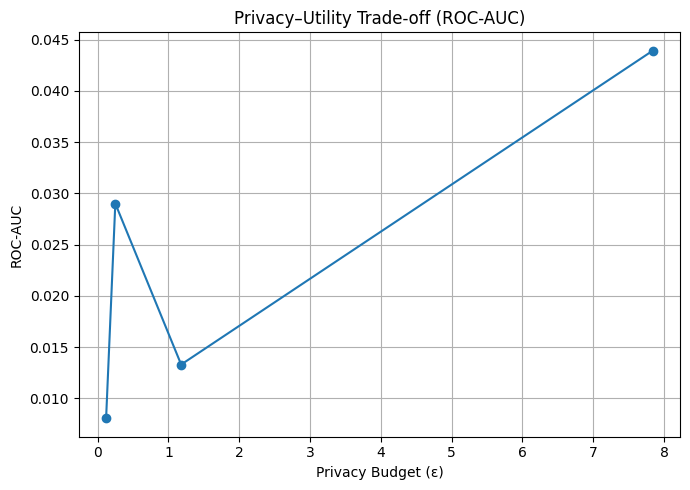

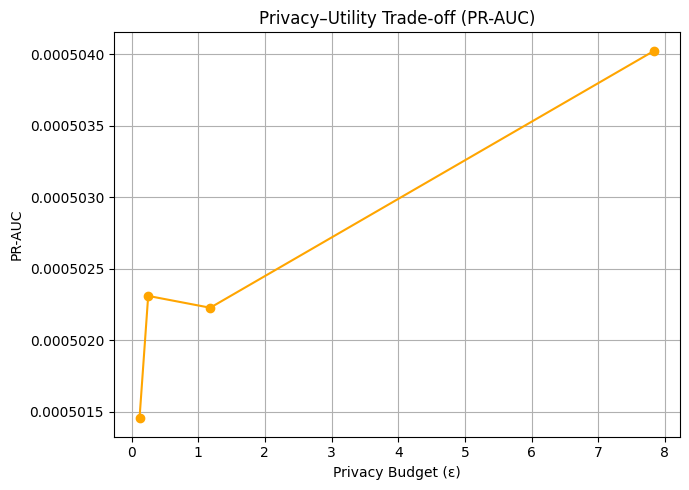

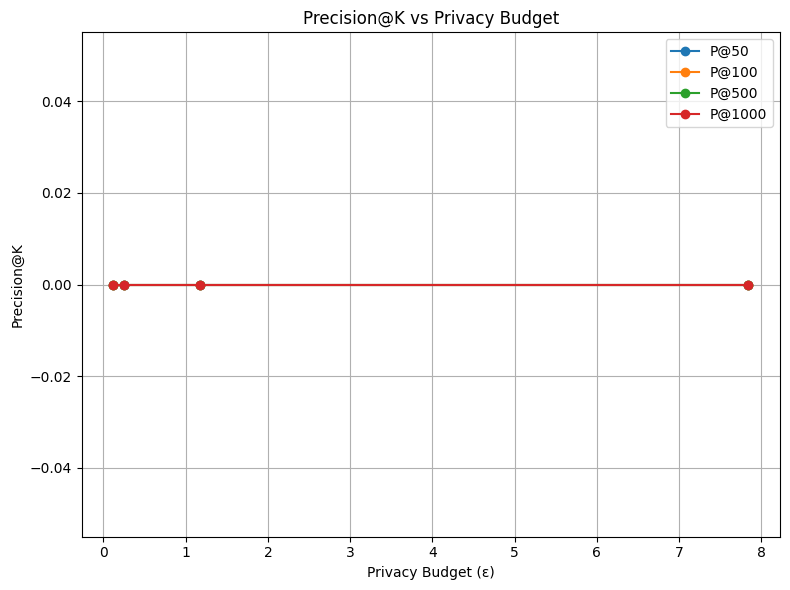

📊 Cell-9 plots generated successfully


In [ ]:
# ===== Cell-9: Privacy–Utility Trade-off Plots (FINAL) =====

import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Load ε-sweep results
# ----------------------------
df = pd.read_csv("/content/epsilon_sweep_results.csv")
print("✅ Loaded ε-sweep results:")
display(df)

# Sort by epsilon (low → high privacy)
df = df.sort_values("epsilon")

# ----------------------------
# Plot 1: ε vs ROC-AUC
# ----------------------------
plt.figure(figsize=(7,5))
plt.plot(df["epsilon"], df["ROC_AUC"], marker="o")
plt.xlabel("Privacy Budget (ε)")
plt.ylabel("ROC-AUC")
plt.title("Privacy–Utility Trade-off (ROC-AUC)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: ε vs PR-AUC
# ----------------------------
plt.figure(figsize=(7,5))
plt.plot(df["epsilon"], df["PR_AUC"], marker="o", color="orange")
plt.xlabel("Privacy Budget (ε)")
plt.ylabel("PR-AUC")
plt.title("Privacy–Utility Trade-off (PR-AUC)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------------------
# Plot 3: ε vs Precision@K
# ----------------------------
plt.figure(figsize=(8,6))

for k in [50, 100, 500, 1000]:
    plt.plot(
        df["epsilon"],
        df[f"P@{k}"],
        marker="o",
        label=f"P@{k}"
    )

plt.xlabel("Privacy Budget (ε)")
plt.ylabel("Precision@K")
plt.title("Precision@K vs Privacy Budget")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("📊 Cell-9 plots generated successfully")
